# Dimensionality Reduction & Unsupervised Clustering

## Objective

Apply Principal Component Analysis (PCA) and unsupervised clustering techniques to discover patterns in student academic and demographic data.

## Dataset

UCI Student Performance Mathematics dataset.

## Methods

- Feature standardization
- Principal Component Analysis (PCA)
- Explained variance analysis
- K-Means clustering
- Elbow Method
- Silhouette Score
- DBSCAN clustering
- Hierarchical clustering
- 2D cluster visualization
- 3D PCA visualization

## Goal

Identify meaningful groups and high-dimensional patterns among students using unsupervised learning techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [4]:
# Load the UCI Student Performance Mathematics dataset

data = pd.read_csv("../raw/student-mat.csv", sep=";")

print("Dataset shape:", data.shape)

data.head()

Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [2]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\yashas\OneDrive\Desktop\Student_Study_Time_Research\.venv\Scripts\python.exe
3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]


In [6]:
%pip install -U scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
print(sys.executable)

c:\Users\yashas\OneDrive\Desktop\Student_Study_Time_Research\.venv\Scripts\python.exe


In [5]:
# Select numerical features for PCA and clustering

features = [
    "age",
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
    "G1",
    "G2",
    "G3"
]

X = data[features].dropna()

print("Number of students:", X.shape[0])
print("Number of features:", X.shape[1])

X.head()

Number of students: 395
Number of features: 16


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,18,4,4,2,2,0,4,3,4,1,1,3,6,5,6,6
1,17,1,1,1,2,0,5,3,3,1,1,3,4,5,5,6
2,15,1,1,1,2,3,4,3,2,2,3,3,10,7,8,10
3,15,4,2,1,3,0,3,2,2,1,1,5,2,15,14,15
4,16,3,3,1,2,0,4,3,2,1,2,5,4,6,10,10


In [8]:
# Standardize the numerical features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardized data shape:", X_scaled.shape)

# Display the first five standardized rows
pd.DataFrame(
    X_scaled,
    columns=features
).head()

Standardized data shape: (395, 16)


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,1.023046,1.143856,1.360371,0.792251,-0.042286,-0.449944,0.062194,-0.236010,0.801479,-0.540699,-1.003789,-0.399289,0.036424,-1.782467,-1.254791,-0.964934
1,0.238380,-1.600009,-1.399970,-0.643249,-0.042286,-0.449944,1.178860,-0.236010,-0.097908,-0.540699,-1.003789,-0.399289,-0.213796,-1.782467,-1.520979,-0.964934
2,-1.330954,-1.600009,-1.399970,-0.643249,-0.042286,3.589323,0.062194,-0.236010,-0.997295,0.583385,0.551100,-0.399289,0.536865,-1.179147,-0.722415,-0.090739
3,-1.330954,1.143856,-0.479857,-0.643249,1.150779,-0.449944,-1.054472,-1.238419,-0.997295,-0.540699,-1.003789,1.041070,-0.464016,1.234133,0.874715,1.002004
4,-0.546287,0.229234,0.440257,-0.643249,-0.042286,-0.449944,0.062194,-0.236010,-0.997295,-0.540699,-0.226345,1.041070,-0.213796,-1.480807,-0.190038,-0.090739


In [6]:
print("data exists:", "data" in globals())
print("data shape:", data.shape)

features = [
    "age", "Medu", "Fedu", "traveltime", "studytime",
    "failures", "famrel", "freetime", "goout",
    "Dalc", "Walc", "health", "absences", "G1", "G2", "G3"
]

print("Missing columns:", [col for col in features if col not in data.columns])

data exists: True
data shape: (395, 33)
Missing columns: []


In [7]:
X = data[features].copy()

print("X created successfully")
print("X shape:", X.shape)

X created successfully
X shape: (395, 16)


In [9]:
# Perform Principal Component Analysis

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Number of principal components:", X_pca.shape[1])

Original number of features: 16
Number of principal components: 16


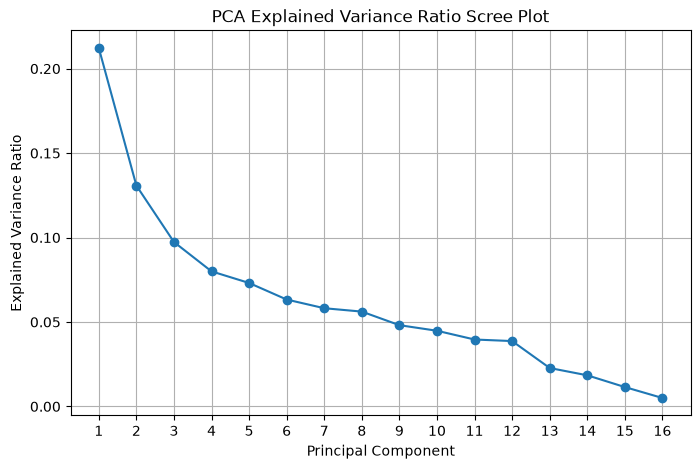

In [10]:
# Explained Variance Ratio Scree Plot

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance Ratio Scree Plot")
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(True)

plt.show()

In [11]:
# Calculate cumulative explained variance

cumulative_variance = np.cumsum(explained_variance)

for i, variance in enumerate(cumulative_variance, start=1):
    print(f"PC{i}: {variance:.4f} ({variance*100:.2f}%)")

PC1: 0.2122 (21.22%)
PC2: 0.3430 (34.30%)
PC3: 0.4404 (44.04%)
PC4: 0.5203 (52.03%)
PC5: 0.5934 (59.34%)
PC6: 0.6567 (65.67%)
PC7: 0.7149 (71.49%)
PC8: 0.7710 (77.10%)
PC9: 0.8192 (81.92%)
PC10: 0.8640 (86.40%)
PC11: 0.9036 (90.36%)
PC12: 0.9423 (94.23%)
PC13: 0.9651 (96.51%)
PC14: 0.9835 (98.35%)
PC15: 0.9950 (99.50%)
PC16: 1.0000 (100.00%)


In [12]:
# Select the optimal number of principal components

n_components = 11

pca_optimal = PCA(n_components=n_components)

X_pca_optimal = pca_optimal.fit_transform(X_scaled)

print("Selected principal components:", n_components)
print("Reduced data shape:", X_pca_optimal.shape)
print(
    "Explained variance:",
    f"{pca_optimal.explained_variance_ratio_.sum() * 100:.2f}%"
)

Selected principal components: 11
Reduced data shape: (395, 11)
Explained variance: 90.36%


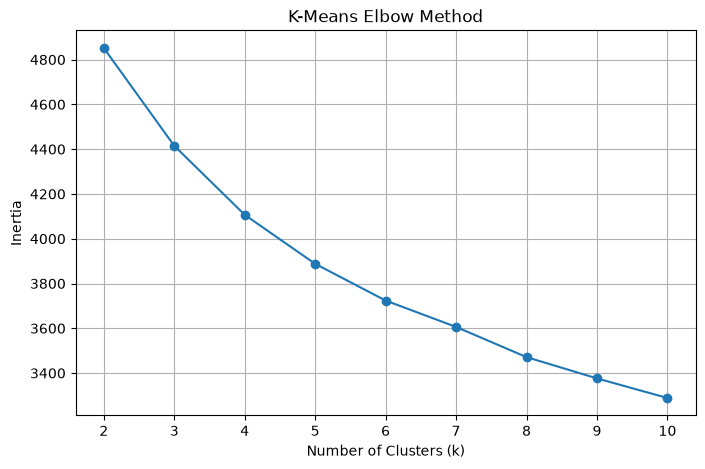

In [13]:
# K-Means Elbow Method

inertia = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_pca_optimal)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(k_values, inertia, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

k = 2: Silhouette Score = 0.1477
k = 3: Silhouette Score = 0.1325
k = 4: Silhouette Score = 0.1130
k = 5: Silhouette Score = 0.1065
k = 6: Silhouette Score = 0.1069
k = 7: Silhouette Score = 0.0965
k = 8: Silhouette Score = 0.0972
k = 9: Silhouette Score = 0.0905
k = 10: Silhouette Score = 0.0948


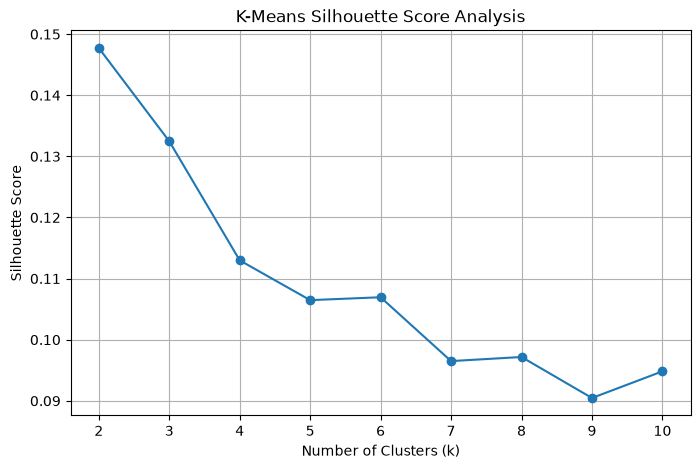

In [14]:
# K-Means Silhouette Score Analysis

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_pca_optimal)
    
    score = silhouette_score(X_pca_optimal, labels)
    silhouette_scores.append(score)
    
    print(f"k = {k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score Analysis")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [15]:
# Apply K-Means clustering with the optimal number of clusters

optimal_k = 2

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X_pca_optimal)

print("Number of clusters:", optimal_k)
print("Cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

print(
    "Final Silhouette Score:",
    f"{silhouette_score(X_pca_optimal, kmeans_labels):.4f}"
)

Number of clusters: 2
Cluster sizes:
0    233
1    162
Name: count, dtype: int64
Final Silhouette Score: 0.1477


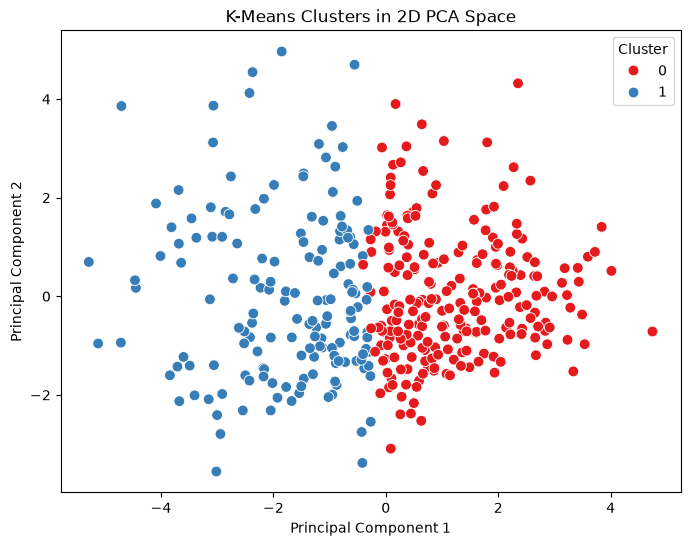

In [16]:
# 2D PCA visualization of K-Means clusters

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca_optimal[:, 0],
    y=X_pca_optimal[:, 1],
    hue=kmeans_labels,
    palette="Set1",
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters in 2D PCA Space")
plt.legend(title="Cluster")

plt.show()

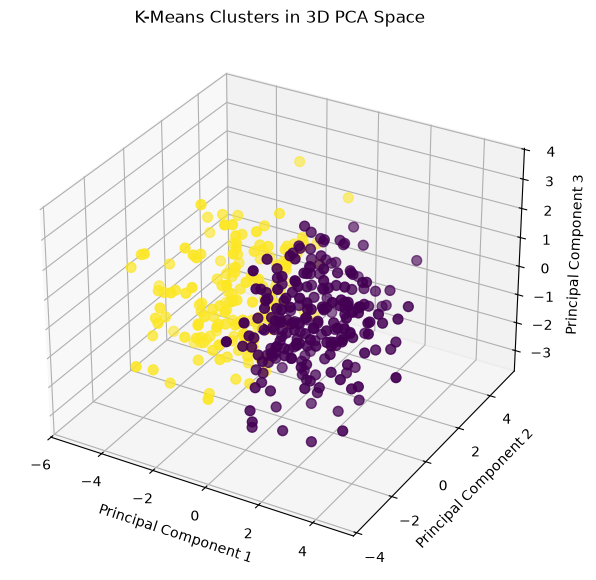

In [17]:
# 3D PCA visualization of K-Means clusters

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_pca_optimal[:, 0],
    X_pca_optimal[:, 1],
    X_pca_optimal[:, 2],
    c=kmeans_labels,
    cmap="viridis",
    s=50
)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("K-Means Clusters in 3D PCA Space")

plt.show()

In [18]:
# DBSCAN clustering

dbscan = DBSCAN(
    eps=2.0,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN cluster labels:")
print(np.unique(dbscan_labels))

print("\nCluster sizes:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN cluster labels:
[-1  0]

Cluster sizes:
-1    390
 0      5
Name: count, dtype: int64


In [19]:
# Try DBSCAN with a larger neighborhood

dbscan = DBSCAN(
    eps=3.0,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN cluster labels:")
print(np.unique(dbscan_labels))

print("\nCluster sizes:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN cluster labels:
[-1  0]

Cluster sizes:
-1    121
 0    274
Name: count, dtype: int64


In [20]:
# Try DBSCAN with eps = 3.5

dbscan = DBSCAN(
    eps=3.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN cluster labels:")
print(np.unique(dbscan_labels))

print("\nCluster sizes:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN cluster labels:
[-1  0]

Cluster sizes:
-1     50
 0    345
Name: count, dtype: int64


In [21]:
# Hierarchical (Agglomerative) Clustering

hierarchical = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_pca_optimal)

print("Number of clusters:", optimal_k)

print("\nCluster sizes:")
print(
    pd.Series(hierarchical_labels)
    .value_counts()
    .sort_index()
)

print(
    "\nSilhouette Score:",
    f"{silhouette_score(X_pca_optimal, hierarchical_labels):.4f}"
)

Number of clusters: 2

Cluster sizes:
0    225
1    170
Name: count, dtype: int64

Silhouette Score: 0.0932


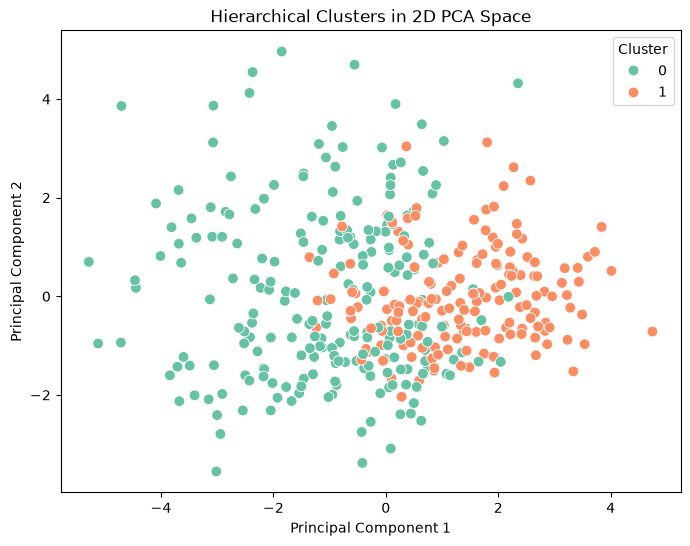

In [22]:
# 2D PCA visualization of Hierarchical Clusters

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca_optimal[:, 0],
    y=X_pca_optimal[:, 1],
    hue=hierarchical_labels,
    palette="Set2",
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clusters in 2D PCA Space")
plt.legend(title="Cluster")

plt.show()

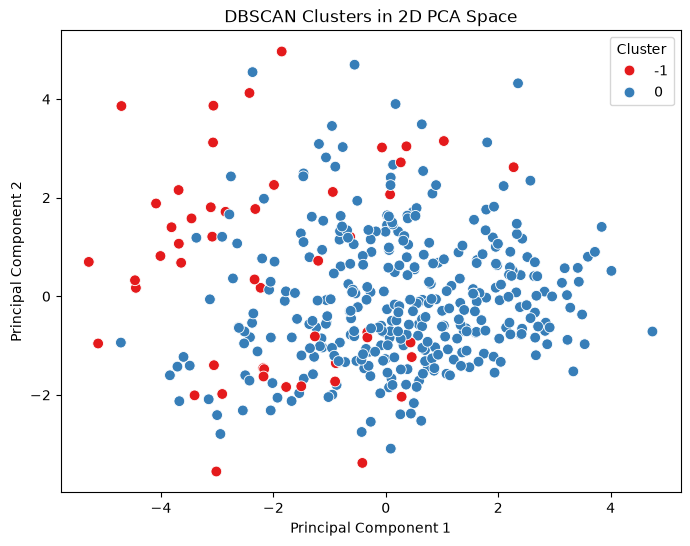

In [23]:
# 2D PCA visualization of DBSCAN clusters

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca_optimal[:, 0],
    y=X_pca_optimal[:, 1],
    hue=dbscan_labels,
    palette="Set1",
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clusters in 2D PCA Space")
plt.legend(title="Cluster")

plt.show()

In [24]:
# Final comparison of clustering methods

kmeans_score = silhouette_score(X_pca_optimal, kmeans_labels)
hierarchical_score = silhouette_score(X_pca_optimal, hierarchical_labels)

# DBSCAN score only for non-noise points
dbscan_mask = dbscan_labels != -1
dbscan_clusters = set(dbscan_labels[dbscan_mask])

if len(dbscan_clusters) >= 2:
    dbscan_score = silhouette_score(
        X_pca_optimal[dbscan_mask],
        dbscan_labels[dbscan_mask]
    )
else:
    dbscan_score = None

print("===== FINAL CLUSTERING RESULTS =====")
print(f"K-Means: {optimal_k} clusters")
print(f"K-Means Silhouette Score: {kmeans_score:.4f}")

print(f"\nHierarchical: {optimal_k} clusters")
print(f"Hierarchical Silhouette Score: {hierarchical_score:.4f}")

print("\nDBSCAN:")
print(f"Clusters found: {len(dbscan_clusters)}")
print(f"Noise points: {sum(dbscan_labels == -1)}")

if dbscan_score is not None:
    print(f"DBSCAN Silhouette Score: {dbscan_score:.4f}")
else:
    print("DBSCAN Silhouette Score: Not applicable because fewer than 2 clusters were formed.")

===== FINAL CLUSTERING RESULTS =====
K-Means: 2 clusters
K-Means Silhouette Score: 0.1477

Hierarchical: 2 clusters
Hierarchical Silhouette Score: 0.0932

DBSCAN:
Clusters found: 1
Noise points: 50
DBSCAN Silhouette Score: Not applicable because fewer than 2 clusters were formed.


# Final Findings

## PCA

- The original dataset contained 16 numerical features.
- PCA was applied after standardizing the features.
- The first 11 principal components explained 90.36% of the total variance.
- Therefore, 11 principal components were selected for clustering.

## K-Means Clustering

- The Elbow Method and Silhouette Score analysis were used to determine the number of clusters.
- The highest Silhouette Score was obtained at k = 2.
- K-Means with 2 clusters achieved a Silhouette Score of 0.1477.

## Hierarchical Clustering

- Agglomerative Hierarchical Clustering was performed using 2 clusters.
- The Silhouette Score was 0.0932.

## DBSCAN Clustering

- DBSCAN was explored using standardized features.
- With eps = 3.5 and min_samples = 5, DBSCAN identified 1 main cluster and 50 noise points.
- A Silhouette Score was not calculated because DBSCAN produced fewer than two clusters.

## Overall Conclusion

PCA successfully reduced the 16-dimensional feature space to 11 principal components while retaining 90.36% of the variance. Among the clustering methods tested, K-Means with 2 clusters produced the highest Silhouette Score (0.1477), indicating the best clustering quality among the tested approaches. Hierarchical clustering produced a lower Silhouette Score, while DBSCAN identified one main group and several noise points.